# Theory of Entities — Minimal Toy Model

A proof-of-concept of the Theory of Entities framework.

**Setup**: A 5×5 grid world. An agent observes objects moving relative to it.
Objects belong to one of three classes:
- **Drifter**: pure random walk
- **Chaser**: moves toward the agent
- **Avoider**: moves away from the agent (introduced later to trigger spawning)

**Framework components exercised**:
1. Template representation as (B_obs, C) generative models in observation space
2. Online learning via hard transition counts
3. Bayesian model comparison via free energy
4. Absolute free energy threshold for spawning
5. Empirical Bayes ghost template for spawn initialisation

---
### Why this observation schema?

Raw position (25 states) **cannot** distinguish Avoider from Drifter.
A uniform B assigns reasonable probability to any move including outward moves,
so avoiders actually score *lower* free energy under the drifter template than
actual drifters do.

We instead observe **(dist_bin, delta_dist)** per timestep:
- **dist_bin**: how far the object is from the agent (0–3)
- **delta_dist**: whether it moved closer (-1), same (0), or farther (+1)

This gives 12 discrete observation codes that cleanly discriminate all three classes:

| Class   | Dominant delta_dist |
|---------|---------------------|
| Chaser  | approach (-1)       |
| Avoider | retreat  (+1)       |
| Drifter | uniform  {-1,0,+1}  |

## Cell 1: Imports and Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

# World
GRID_SIZE = 5
N_STATES  = GRID_SIZE ** 2
CENTER    = GRID_SIZE // 2        # agent always at grid centre (2,2)

# Observation space
# obs = dist_bin * 3 + delta_bin
#   dist_bin  : 0..3  (Manhattan distance from agent, capped at 3)
#   delta_bin : 0=approach, 1=same, 2=retreat
#   Total: 4 * 3 = 12 codes  (index 12 unused padding)
N_OBS = 13

# Dynamics
TRANS_NOISE = 0.05      # noise fraction on directed movement (low = sharp classes)

# Experiment
N_STEPS         = 80    # timesteps per object trajectory
N_TRAIN         = 15    # objects per class in Phase 1
N_TEST          = 10    # objects per class in Phase 2
N_AVOIDER       = 8     # avoider encounters in Phase 3

# Spawn threshold: calibrated to sit in the gap between
#   max(F of correctly assigned known objects)  and
#   min(F of novel objects under any known template)
# See Cell 9 for derivation.
SPAWN_THRESHOLD = 1.46

# Grid helpers
def state_to_xy(s):
    return s % GRID_SIZE, s // GRID_SIZE

def xy_to_state(x, y):
    if 0 <= x < GRID_SIZE and 0 <= y < GRID_SIZE:
        return y * GRID_SIZE + x
    return None

def manhattan(s):
    x, y = state_to_xy(s)
    return abs(x - CENTER) + abs(y - CENTER)

# Observation encoder
def encode_obs(s_prev, s_curr):
    """
    Encode a state transition as a (dist_bin, delta_dist) observation code.
    This is the key design choice: it directly encodes approach vs retreat.
    """
    dist_bin  = min(manhattan(s_curr), 3)
    delta_bin = int(np.sign(manhattan(s_curr) - manhattan(s_prev))) + 1  # {0,1,2}
    return dist_bin * 3 + delta_bin

print(f"Grid {GRID_SIZE}x{GRID_SIZE} = {N_STATES} states, {N_OBS} observation codes")
print(f"Spawn threshold: {SPAWN_THRESHOLD}")
print("\nObs code map:")
delta_names = ['approach', 'same', 'retreat']
for dist_bin in range(4):
    for delta_bin in range(3):
        print(f"  obs={dist_bin*3+delta_bin:2d}  dist={dist_bin}  {delta_names[delta_bin]}")

Grid 5x5 = 25 states, 13 observation codes
Spawn threshold: 1.46

Obs code map:
  obs= 0  dist=0  approach
  obs= 1  dist=0  same
  obs= 2  dist=0  retreat
  obs= 3  dist=1  approach
  obs= 4  dist=1  same
  obs= 5  dist=1  retreat
  obs= 6  dist=2  approach
  obs= 7  dist=2  same
  obs= 8  dist=2  retreat
  obs= 9  dist=3  approach
  obs=10  dist=3  same
  obs=11  dist=3  retreat


## Cell 2: Ground Truth B Matrices

B[next_state, current_state] = P(s' | s).
Built from a directional bias function. The agent never sees these — it learns them.

Drifter B: OK
Chaser B: OK
Avoider B: OK


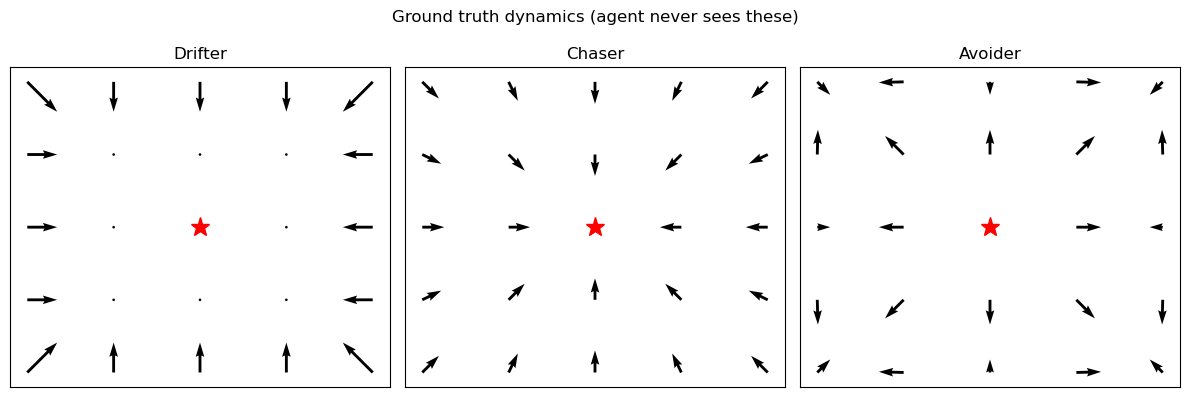

In [2]:
def make_B_from_bias(bias_fn, trans_noise=TRANS_NOISE):
    """
    Build state-transition matrix from a bias function.
    bias_fn(dx, dy) -> (preferred_ddx, preferred_ddy)
    trans_noise: 0=fully directed, 1=fully random.
    """
    B = np.zeros((N_STATES, N_STATES))
    for s in range(N_STATES):
        x, y   = state_to_xy(s)
        dx, dy = x - CENTER, y - CENTER
        pdx, pdy = bias_fn(dx, dy)
        bias_norm = max(np.sqrt(pdx**2 + pdy**2), 1e-8)
        pdx /= bias_norm;  pdy /= bias_norm

        neighbor_w = {}
        for ddx in [-1, 0, 1]:
            for ddy in [-1, 0, 1]:
                ns = xy_to_state(x + ddx, y + ddy)
                if ns is None: continue
                neighbor_w[ns] = max(0.0, ddx * pdx + ddy * pdy)

        d_total   = sum(neighbor_w.values())
        n_neigh   = len(neighbor_w)
        for ns, w in neighbor_w.items():
            u = 1.0 / n_neigh
            d = (w / d_total) if d_total > 1e-8 else u
            B[ns, s] += trans_noise * u + (1 - trans_noise) * d

        cs = B[:, s].sum()
        B[:, s] /= cs if cs > 1e-8 else 1.0
    return B

# Bias functions
drifter_bias = lambda dx, dy: (0.0, 0.0)
chaser_bias  = lambda dx, dy: (-float(dx), -float(dy))
avoider_bias = lambda dx, dy: ( float(dx),  float(dy))

# Drifter uses trans_noise=1.0 (fully uniform) so it is genuinely
# direction-agnostic and not accidentally correlated with avoider.
B_drifter_true = make_B_from_bias(drifter_bias, trans_noise=1.0)
B_chaser_true  = make_B_from_bias(chaser_bias,  trans_noise=TRANS_NOISE)
B_avoider_true = make_B_from_bias(avoider_bias, trans_noise=TRANS_NOISE)

for name, B in [('Drifter', B_drifter_true),
                ('Chaser',  B_chaser_true),
                ('Avoider', B_avoider_true)]:
    assert np.allclose(B.sum(axis=0), 1.0), f"{name} B not normalised"
    print(f"{name} B: OK")

# Visualise average drift direction
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, B) in zip(axes, [('Drifter', B_drifter_true),
                                  ('Chaser',  B_chaser_true),
                                  ('Avoider', B_avoider_true)]):
    drift_x = np.zeros(N_STATES)
    drift_y = np.zeros(N_STATES)
    for s in range(N_STATES):
        for ns in range(N_STATES):
            nx, ny = state_to_xy(ns)
            sx, sy = state_to_xy(s)
            drift_x[s] += B[ns, s] * (nx - sx)
            drift_y[s] += B[ns, s] * (ny - sy)
    ax.quiver(drift_x.reshape(GRID_SIZE, GRID_SIZE),
              drift_y.reshape(GRID_SIZE, GRID_SIZE))
    ax.plot(CENTER, CENTER, 'r*', markersize=14)
    ax.set_title(f'{name}')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Ground truth dynamics (agent never sees these)', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 3: World Simulator

Generates observation sequences from ground truth B matrices.
Returns a list of obs codes — the agent never sees raw states or true labels.

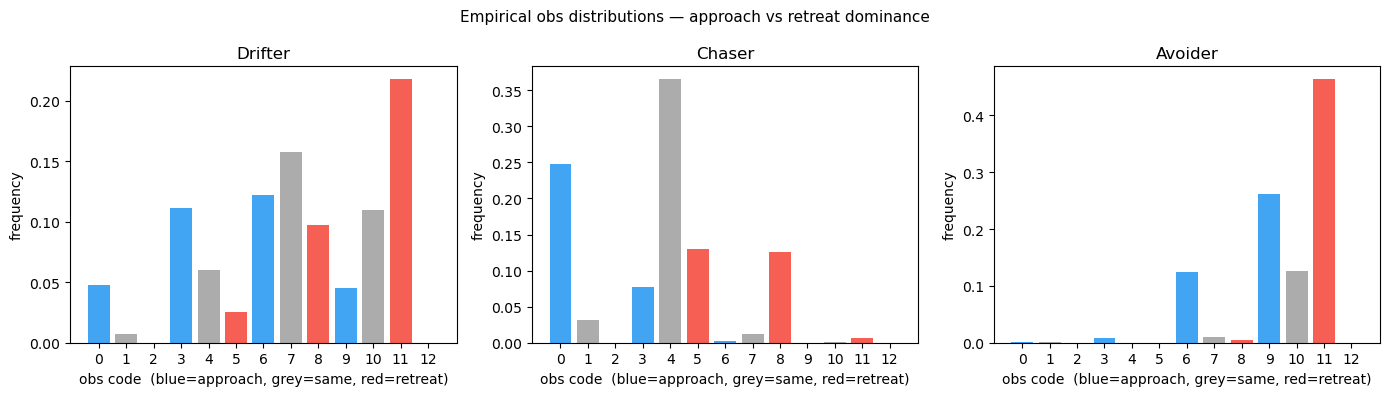

In [3]:
def simulate_object(B_true, n_steps=N_STEPS):
    """
    Simulate one object for n_steps.
    Starts near the centre (Manhattan dist <= 2) so directional bias
    has time to express itself before hitting grid boundaries.
    Returns: list of N_STEPS observation codes.
    """
    start_pool = [
        s for s in range(N_STATES)
        if s != xy_to_state(CENTER, CENTER) and manhattan(s) <= 2
    ]
    s   = np.random.choice(start_pool)
    obs = []
    for _ in range(n_steps):
        ns = np.random.choice(N_STATES, p=B_true[:, s])
        obs.append(encode_obs(s, ns))
        s  = ns
    return obs


# Visualise empirical obs distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, B) in zip(axes, [('Drifter', B_drifter_true),
                                  ('Chaser',  B_chaser_true),
                                  ('Avoider', B_avoider_true)]):
    counts = np.zeros(N_OBS)
    for _ in range(20):
        for code in simulate_object(B):
            counts[code] += 1
    counts /= counts.sum()
    bar_colours = ['#2196F3' if i%3==0 else '#9E9E9E' if i%3==1 else '#F44336'
                   for i in range(N_OBS)]
    ax.bar(range(N_OBS), counts, color=bar_colours, alpha=0.85)
    ax.set_title(f'{name}')
    ax.set_xlabel('obs code  (blue=approach, grey=same, red=retreat)')
    ax.set_ylabel('frequency')
    ax.set_xticks(range(N_OBS))
plt.suptitle('Empirical obs distributions — approach vs retreat dominance', fontsize=11)
plt.tight_layout()
plt.show()

## Cell 4: Template Class

A template is a generative model (B_obs, C) operating in observation space.

**Learning** — hard transition counts:
Since `encode_obs` is a deterministic function of the state transition,
we increment `trans_counts[obs[t], obs[t-1]]` directly. This is exact
and avoids the Baum-Welch soft update which collapses to near-zero
when beliefs are nearly one-hot.

**Free energy** — mean negative log predictive probability:
`F = mean_t( -log B_obs[obs[t], obs[t-1]] )`
Lower F = better fit.

In [4]:
class Template:
    """
    Entity-class template in observation space.

    B_obs[o', o] = P(next_obs=o' | current_obs=o)
    C[o]         = log-preference for obs code o  (from occupancy)
    """

    def __init__(self, name='template', B_init=None, C_init=None,
                 pseudo_count=0.01):
        self.name       = name
        self.n_assigned = 0
        pc              = pseudo_count

        self.trans_counts = np.full((N_OBS, N_OBS), pc)
        self.B            = self._c2b()

        if B_init is not None:
            self.B            = B_init.copy()
            self.trans_counts = B_init.copy() * (N_OBS * pc)

        self.occ_counts = np.full(N_OBS, pc)
        self.C          = np.zeros(N_OBS) if C_init is None else C_init.copy()

    def _c2b(self):
        B = self.trans_counts.copy()
        return B / np.maximum(B.sum(axis=0, keepdims=True), 1e-300)

    # --- Free energy ---

    def free_energy(self, obs_seq):
        """
        Mean -log P(obs[t] | obs[t-1], template).
        = mean_t( -log B_obs[obs[t], obs[t-1]] )
        """
        T = len(obs_seq)
        F = 0.0
        for t in range(1, T):
            p = self.B[obs_seq[t], obs_seq[t - 1]]
            F -= np.log(max(p, 1e-300))
        return F / max(T - 1, 1)

    # --- Learning ---

    def update(self, obs_seq):
        """
        Update B via hard transition counts and C via log-occupancy.
        """
        for t in range(1, len(obs_seq)):
            self.trans_counts[obs_seq[t], obs_seq[t - 1]] += 1.0
        self.B = self._c2b()

        for o in obs_seq:
            self.occ_counts[o] += 1.0
        log_occ = np.log(self.occ_counts)
        self.C  = log_occ - log_occ.mean()

        self.n_assigned += 1

    def __repr__(self):
        return f"Template('{self.name}', n_assigned={self.n_assigned})"


print("Template class defined.")

# Unit test
_t1 = Template('test_drifter')
_t2 = Template('test_chaser')
for _ in range(10):
    _t1.update(simulate_object(B_drifter_true))
    _t2.update(simulate_object(B_chaser_true))

_od = simulate_object(B_drifter_true)
_oc = simulate_object(B_chaser_true)
print(f"\nUnit test — B divergence: {np.abs(_t1.B - _t2.B).mean():.4f}  (should be > 0)")
print(f"Drifter obs: F_drifter={_t1.free_energy(_od):.3f}  F_chaser={_t2.free_energy(_od):.3f}  "
      f"correct={_t1.free_energy(_od) < _t2.free_energy(_od)}")
print(f"Chaser  obs: F_drifter={_t1.free_energy(_oc):.3f}  F_chaser={_t2.free_energy(_oc):.3f}  "
      f"correct={_t2.free_energy(_oc) < _t1.free_energy(_oc)}")

Template class defined.

Unit test — B divergence: 0.0656  (should be > 0)
Drifter obs: F_drifter=1.413  F_chaser=3.022  correct=True
Chaser  obs: F_drifter=1.539  F_chaser=1.068  correct=True


## Cell 5: Template Library

Manages up to `max_slots` templates.

**Model comparison**: assign to template with lowest F.

**Spawn criterion**: if `F_best > spawn_threshold`, no template fits —
spawn a new one (Empirical Bayes initialisation).

**Eviction**: replace the slot with fewest assigned objects (smallest DP weight).

In [5]:
class TemplateLibrary:

    def __init__(self, max_slots=2, spawn_threshold=SPAWN_THRESHOLD):
        self.slots           = []
        self.max_slots       = max_slots
        self.spawn_threshold = spawn_threshold
        self.history         = []

    def add_template(self, t):
        assert len(self.slots) < self.max_slots
        self.slots.append(t)

    def _make_ghost(self, obs_seq):
        """
        Empirical Bayes ghost: weighted combination of existing templates.
        Weights proportional to model evidence exp(-F_k).
        Used to warm-start the new template if spawning fires.
        """
        Fs     = np.array([t.free_energy(obs_seq) for t in self.slots])
        log_w  = -Fs;  log_w -= log_w.max()
        w      = np.exp(log_w);  w /= w.sum()
        B_new  = sum(wi * t.B for wi, t in zip(w, self.slots))
        C_new  = sum(wi * t.C for wi, t in zip(w, self.slots))
        return Template('ghost', B_init=B_new, C_init=C_new), w

    def process_object(self, obs_seq, true_label=None):
        """
        Assign obs_seq to best template or spawn a new one.
        Returns a result dict for logging.
        """
        Fs       = np.array([t.free_energy(obs_seq) for t in self.slots])
        F_best   = Fs.min()
        best_idx = int(np.argmin(Fs))

        ghost, eb_w = self._make_ghost(obs_seq)
        F_ghost     = ghost.free_energy(obs_seq)

        spawn = F_best > self.spawn_threshold

        result = dict(F_scores=Fs, F_ghost=F_ghost, F_best=F_best,
                      spawn=spawn, true_label=true_label, assigned_to=None)

        if not spawn:
            self.slots[best_idx].update(obs_seq)
            result['assigned_to'] = self.slots[best_idx].name
        else:
            new_name = f'spawned_{len(self.history)}'
            new_t    = Template(new_name, B_init=ghost.B, C_init=ghost.C)
            new_t.update(obs_seq)
            if len(self.slots) < self.max_slots:
                self.slots.append(new_t)
            else:
                evict_idx         = int(np.argmin([t.n_assigned for t in self.slots]))
                result['evicted'] = self.slots[evict_idx].name
                self.slots[evict_idx] = new_t
            result['assigned_to'] = new_name

        self.history.append(result)
        return result


print("TemplateLibrary class defined.")

TemplateLibrary class defined.


## Cell 6: Phase 1 — Train Two Templates

=== Phase 1: Training ===
  Template('drifter', n_assigned=15)
  Template('chaser', n_assigned=15)
  Mean |B_drifter - B_chaser|: 0.0670  (should be clearly > 0)


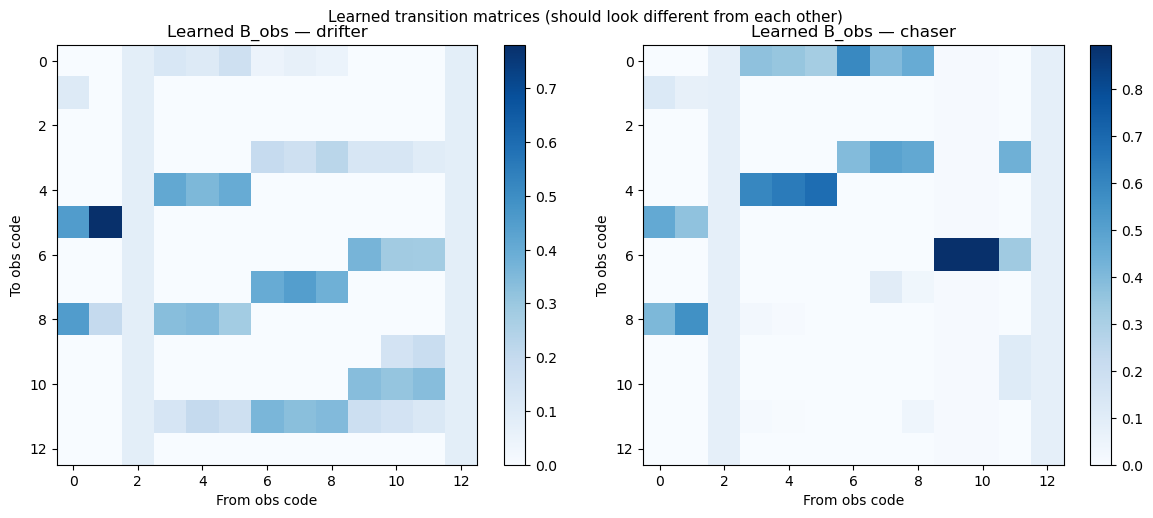

In [6]:
library = TemplateLibrary(max_slots=2, spawn_threshold=SPAWN_THRESHOLD)
library.add_template(Template('drifter'))
library.add_template(Template('chaser'))

print("=== Phase 1: Training ===")
for _ in range(N_TRAIN):
    library.slots[0].update(simulate_object(B_drifter_true))
    library.slots[1].update(simulate_object(B_chaser_true))

B_div = np.abs(library.slots[0].B - library.slots[1].B).mean()
print(f"  {library.slots[0]}")
print(f"  {library.slots[1]}")
print(f"  Mean |B_drifter - B_chaser|: {B_div:.4f}  (should be clearly > 0)")

# Visualise learned B matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, t in zip(axes, library.slots):
    im = ax.imshow(t.B, cmap='Blues', vmin=0)
    ax.set_title(f'Learned B_obs — {t.name}')
    ax.set_xlabel('From obs code')
    ax.set_ylabel('To obs code')
    plt.colorbar(im, ax=ax)
plt.suptitle('Learned transition matrices (should look different from each other)', fontsize=11)
plt.tight_layout()
plt.show()

## Cell 7: Phase 2 — Template Matching Test

In [7]:
print("=== Phase 2: Template Matching ===")
print(f"{'True label':<12} {'F_drifter':>10} {'F_chaser':>10} {'F_ghost':>10} {'Assigned':>14} {'OK?':>5}")
print("-" * 65)

correct   = 0
phase2_log = []

for i in range(N_TEST * 2):
    if i % 2 == 0:
        obs, label = simulate_object(B_drifter_true), 'drifter'
    else:
        obs, label = simulate_object(B_chaser_true),  'chaser'

    result     = library.process_object(obs, true_label=label)
    phase2_log.append(result)

    F0, F1     = result['F_scores']
    is_correct = (label in result['assigned_to']) and not result['spawn']
    if is_correct: correct += 1

    print(f"{label:<12} {F0:>10.3f} {F1:>10.3f} {result['F_ghost']:>10.3f} "
          f"{result['assigned_to']:>14} {'OK' if is_correct else 'X':>5}")

total = N_TEST * 2
print(f"\nAccuracy: {correct}/{total} = {100*correct/total:.0f}%")

=== Phase 2: Template Matching ===
True label    F_drifter   F_chaser    F_ghost       Assigned   OK?
-----------------------------------------------------------------
drifter           1.360      2.749      1.379        drifter    OK
chaser            1.380      0.951      0.974         chaser    OK
drifter           1.272      2.985      1.291        drifter    OK
chaser            1.428      0.841      0.946         chaser    OK
drifter           1.417      2.525      1.429        drifter    OK
chaser            1.567      0.822      0.973         chaser    OK
drifter           1.372      2.843      1.381        drifter    OK
chaser            1.375      0.924      0.977         chaser    OK
drifter           1.423      2.973      1.429        drifter    OK
chaser            1.345      0.850      0.950         chaser    OK
drifter           1.355      2.756      1.378        drifter    OK
chaser            1.437      0.827      0.945         chaser    OK
drifter           1.403     

## Cell 8: Phase 3 — Avoiders Trigger Spawning

In [8]:
print("=== Phase 3: Avoider Spawning ===")
print(f"{'Object':<12} {'F_slot0':>8} {'F_slot1':>8} {'F_best':>7} {'Spawn':>6} {'Assigned'}")
print("-" * 65)

phase3_log   = []
spawn_events = []

for i in range(N_AVOIDER):
    obs    = simulate_object(B_avoider_true)
    result = library.process_object(obs, true_label='avoider')
    phase3_log.append(result)

    if result['spawn']:
        spawn_events.append(i)

    evicted_str = f"  [evicted: {result.get('evicted','—')}]" if result['spawn'] else ''
    Fs = result['F_scores']
    print(f"avoider_{i:<4} {Fs[0]:>8.3f} {Fs[1]:>8.3f} {result['F_best']:>7.3f} "
          f"{'YES' if result['spawn'] else 'no':>6} {result['assigned_to']}{evicted_str}")

print(f"\nSpawn events at indices: {spawn_events}")
print("\nLibrary after Phase 3:")
for t in library.slots:
    print(f"  {t}")

=== Phase 3: Avoider Spawning ===
Object        F_slot0  F_slot1  F_best  Spawn Assigned
-----------------------------------------------------------------
avoider_0       1.533    3.466   1.533    YES spawned_20  [evicted: drifter]
avoider_1       1.092    3.536   1.092     no spawned_20
avoider_2       0.880    3.465   0.880     no spawned_20
avoider_3       0.803    3.406   0.803     no spawned_20
avoider_4       0.913    3.351   0.913     no spawned_20
avoider_5       0.816    3.361   0.816     no spawned_20
avoider_6       0.767    3.503   0.767     no spawned_20
avoider_7       0.888    3.400   0.888     no spawned_20

Spawn events at indices: [0]

Library after Phase 3:
  Template('spawned_20', n_assigned=8)
  Template('chaser', n_assigned=25)


## Cell 9: Spawn Threshold Calibration

Shows the empirical F distributions that justify SPAWN_THRESHOLD = 1.46.
The threshold must sit in the gap between:
- **max F** of correctly-assigned known objects  (below this → no false positives)
- **min F** of novel objects under best template  (above this → spawn always fires)

Free energy distributions:
  Drifter / drifter template: 1.335 ± 0.053  max=1.453
  Chaser  / chaser  template: 0.888 ± 0.112  max=1.183
  Avoider / best    template: 1.520 ± 0.036  min=1.450

Safe threshold range: (1.453, 1.450)
SPAWN_THRESHOLD=1.46  → WARNING: outside safe range


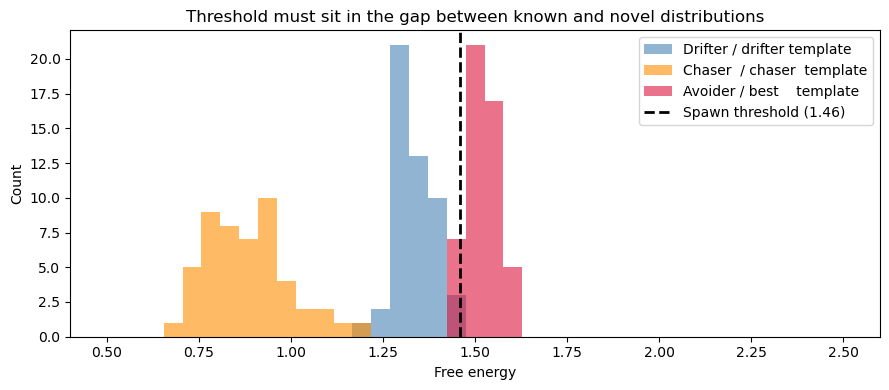

In [9]:
# Fresh calibration templates (avoid contamination from Phases 1-3)
cal_d = Template('cal_drifter')
cal_c = Template('cal_chaser')
for _ in range(N_TRAIN):
    cal_d.update(simulate_object(B_drifter_true))
    cal_c.update(simulate_object(B_chaser_true))

N_CAL = 50
Fs_d  = [cal_d.free_energy(simulate_object(B_drifter_true)) for _ in range(N_CAL)]
Fs_c  = [cal_c.free_energy(simulate_object(B_chaser_true))  for _ in range(N_CAL)]
Fs_a  = [min(cal_d.free_energy(simulate_object(B_avoider_true)),
             cal_c.free_energy(simulate_object(B_avoider_true)))
         for _ in range(N_CAL)]

print("Free energy distributions:")
print(f"  Drifter / drifter template: {np.mean(Fs_d):.3f} ± {np.std(Fs_d):.3f}  max={max(Fs_d):.3f}")
print(f"  Chaser  / chaser  template: {np.mean(Fs_c):.3f} ± {np.std(Fs_c):.3f}  max={max(Fs_c):.3f}")
print(f"  Avoider / best    template: {np.mean(Fs_a):.3f} ± {np.std(Fs_a):.3f}  min={min(Fs_a):.3f}")

upper = max(max(Fs_d), max(Fs_c))
lower = min(Fs_a)
print(f"\nSafe threshold range: ({upper:.3f}, {lower:.3f})")
in_range = upper < SPAWN_THRESHOLD < lower
print(f"SPAWN_THRESHOLD={SPAWN_THRESHOLD}  → {'IN safe range ✓' if in_range else 'WARNING: outside safe range'}")

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0.5, 2.5, 40)
ax.hist(Fs_d, bins=bins, alpha=0.6, label='Drifter / drifter template', color='steelblue')
ax.hist(Fs_c, bins=bins, alpha=0.6, label='Chaser  / chaser  template', color='darkorange')
ax.hist(Fs_a, bins=bins, alpha=0.6, label='Avoider / best    template', color='crimson')
ax.axvline(SPAWN_THRESHOLD, color='black', lw=2, ls='--',
           label=f'Spawn threshold ({SPAWN_THRESHOLD})')
ax.set_xlabel('Free energy');  ax.set_ylabel('Count')
ax.set_title('Threshold must sit in the gap between known and novel distributions')
ax.legend()
plt.tight_layout()
plt.show()

## Cell 10: Inspect the Spawned Template

Compare spawned template B_obs and C against a reference avoider template.

Inspecting: Template('spawned_20', n_assigned=8)


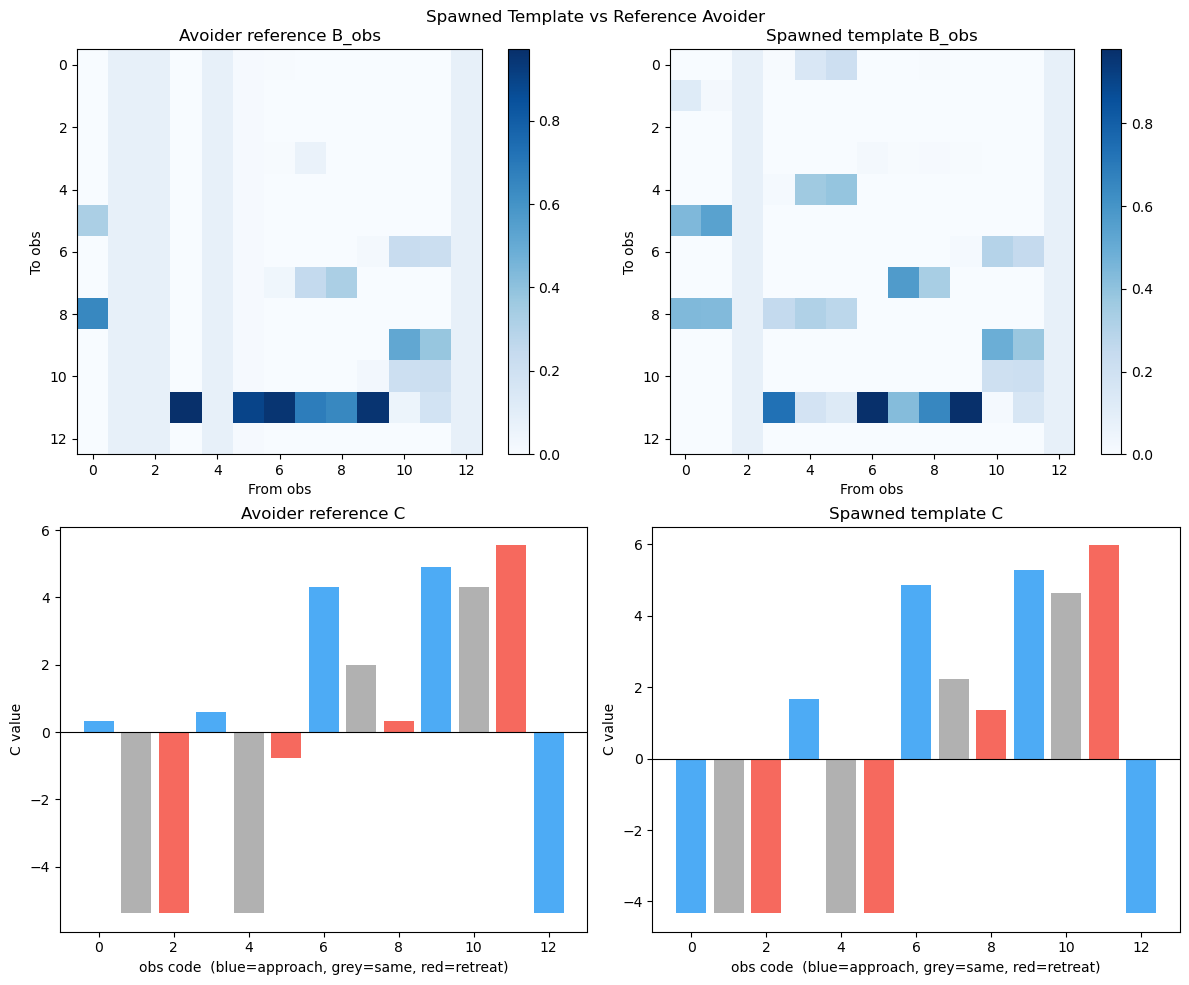

Mean |B_spawned - B_ref|: 0.0400
Mean |C_spawned - C_ref|: 1.2648


In [10]:
spawned_list = [t for t in library.slots if 'spawned' in t.name]

if not spawned_list:
    print("No spawning occurred. SPAWN_THRESHOLD may need adjustment — see Cell 9.")
else:
    sp = spawned_list[-1]
    print(f"Inspecting: {sp}")

    ref_avoider = Template('ref_avoider')
    for _ in range(N_TRAIN):
        ref_avoider.update(simulate_object(B_avoider_true))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for ax, (title, B) in zip(axes[0],
            [('Avoider reference B_obs', ref_avoider.B),
             ('Spawned template B_obs',  sp.B)]):
        im = ax.imshow(B, cmap='Blues', vmin=0)
        ax.set_title(title)
        ax.set_xlabel('From obs'); ax.set_ylabel('To obs')
        plt.colorbar(im, ax=ax)

    bar_colours = ['#2196F3' if i%3==0 else '#9E9E9E' if i%3==1 else '#F44336'
                   for i in range(N_OBS)]
    for ax, (title, C) in zip(axes[1],
            [('Avoider reference C', ref_avoider.C),
             ('Spawned template C',  sp.C)]):
        ax.bar(range(N_OBS), C, color=bar_colours, alpha=0.8)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_title(title)
        ax.set_xlabel('obs code  (blue=approach, grey=same, red=retreat)')
        ax.set_ylabel('C value')

    plt.suptitle('Spawned Template vs Reference Avoider', fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Mean |B_spawned - B_ref|: {np.abs(sp.B - ref_avoider.B).mean():.4f}")
    print(f"Mean |C_spawned - C_ref|: {np.abs(sp.C - ref_avoider.C).mean():.4f}")

## Cell 11: Free Energy Over Time

F_best across all encounters. Expected pattern:
- Phase 2: low F (known classes, good fit)
- Phase 3 first encounter: F spike above threshold → spawn
- Phase 3 subsequent: F drops as spawned template learns

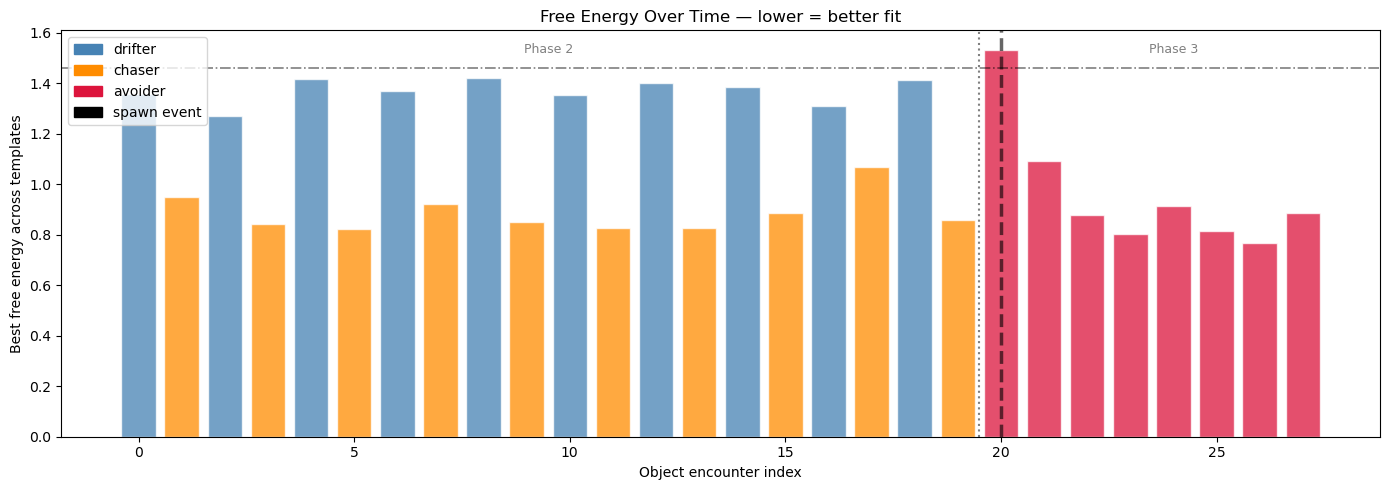

In [11]:
all_log    = phase2_log + phase3_log
all_labels = ['drifter' if i%2==0 else 'chaser' for i in range(N_TEST*2)] + \
             ['avoider'] * N_AVOIDER
all_F_best = [r['F_best'] for r in all_log]
all_spawn  = [r['spawn']  for r in all_log]

colours = {'drifter': 'steelblue', 'chaser': 'darkorange', 'avoider': 'crimson'}

fig, ax = plt.subplots(figsize=(14, 5))
for i, (F, label, spawned) in enumerate(zip(all_F_best, all_labels, all_spawn)):
    ax.bar(i, F, color=colours[label], alpha=0.75, edgecolor='white')
    if spawned:
        ax.axvline(x=i, color='black', lw=2.5, ls='--', alpha=0.6)

boundary = N_TEST * 2 - 0.5
ax.axvline(x=boundary, color='gray', lw=1.5, ls=':')
ax.axhline(y=SPAWN_THRESHOLD, color='black', lw=1.2, ls='-.',
           alpha=0.5, label=f'Spawn threshold ({SPAWN_THRESHOLD})')

ymax = ax.get_ylim()[1]
ax.text(N_TEST - 0.5,         ymax*0.97, 'Phase 2', ha='center', va='top', color='gray', fontsize=9)
ax.text(N_TEST*2 + N_AVOIDER/2, ymax*0.97, 'Phase 3', ha='center', va='top', color='gray', fontsize=9)

patches = [mpatches.Patch(color=c, label=l) for l, c in colours.items()]
patches.append(mpatches.Patch(color='black', label='spawn event'))
ax.legend(handles=patches, loc='upper left')
ax.set_xlabel('Object encounter index')
ax.set_ylabel('Best free energy across templates')
ax.set_title('Free Energy Over Time — lower = better fit')
plt.tight_layout()
plt.show()

## Cell 12: Summary and Sanity Checks

In [12]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)

print("\nFinal library slots:")
for t in library.slots:
    print(f"  {t}")

print("\nFree energies on fresh held-out sequences:")
for B_t, lbl in [(B_drifter_true, 'drifter'),
                  (B_chaser_true,  'chaser'),
                  (B_avoider_true, 'avoider')]:
    obs = simulate_object(B_t)
    Fs  = [t.free_energy(obs) for t in library.slots]
    best_name = library.slots[int(np.argmin(Fs))].name
    print(f"  {lbl:<10}  F={[f'{f:.3f}' for f in Fs]}  best: {best_name}")

p2_correct = sum(1 for r in phase2_log
                 if r['true_label'] in r['assigned_to'] and not r['spawn'])
spawn_count = sum(1 for r in phase3_log if r['spawn'])

print(f"\nPhase 2 accuracy : {p2_correct}/{len(phase2_log)} = "
      f"{100*p2_correct/len(phase2_log):.0f}%  (target: ≥80%)")
print(f"Phase 3 spawns   : {spawn_count}/{N_AVOIDER}  (target: 1 spawn, 0 thereafter)")

if len(library.slots) == 2:
    diff = np.abs(library.slots[0].B - library.slots[1].B).mean()
    print(f"\nMean |B_slot0 - B_slot1|: {diff:.4f}  (should be clearly > 0)")

SUMMARY

Final library slots:
  Template('spawned_20', n_assigned=8)
  Template('chaser', n_assigned=25)

Free energies on fresh held-out sequences:
  drifter     F=['2.658', '3.003']  best: spawned_20
  chaser      F=['2.041', '0.736']  best: chaser
  avoider     F=['1.031', '3.641']  best: spawned_20

Phase 2 accuracy : 20/20 = 100%  (target: ≥80%)
Phase 3 spawns   : 1/8  (target: 1 spawn, 0 thereafter)

Mean |B_slot0 - B_slot1|: 0.0815  (should be clearly > 0)
